<div class="alert alert-info" style="background-color:#001b79; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>Support Vector Machine </h2>
</div>

- Its Supervised algorithm, which can be used for both Regression and Classification challenges.
- It tries to define hyperplane, which can split the data in most optimal way
- This is most efficient algorithm in ML
- To use SVM, parameter selection or parameter Tuning c and Gamma is very important
- Scikit Learn  GridSearchCV takes care of all the hard work  of this parameter slection
- This Gridsearch used in "SVM_College" example
- Its one of the Linear model or linear classifier for classification problem



### Types of Kernel:	
	
###### 1. Linear Kernel: (LSVM - Linear Support Vector Machine)
	
	
       This is linear seperable dataset related kernels. 	


######  Here Below these kernels formula will converts dataset from lower dimension(Orginal space) to Higher Dimension(Transformed Feature space), so it becomes easily separable linearly. This new space is  called transformed feature space.	

######  Kernelized SVM tries to find the decision boundary with maximum margin between classes using a linear classifier in the transformed feature space not the original input space.	
    - Below 2 are called Kernalized Support vector machines	
	
######  2.Polynomial Kernel

            When data is non linearly separable, and can be classified using a curve.
            Degree needed in Plolynomial kernel. It controls complexity and the computational cost of the transformation. c and gamma needed
	
######  3.RBF( Gausaian Radial Basis Function)
    
        When data is non linearly separable, and can't be classified using a curve.
        By default kernel is RBF kernal in SVM.  c and gamma needed
	
######   4.Sigmoid
######   5.Precomputed


### C value:			
	The strength of regularization is determined by C. This is Regularization parameter.	
    
		> Larger Value of C, Less regularization and margin is less
			It fits the training data as well as possible with these few errors as possible,
			Each Individual data point is important to classify correctly
            
		> Smaller Value of C, More regularization  and margin is more
			More tolerent of errors on individual data points
			Very small values of C on the other hand use more regularization that encourages the classifier to find a large marge on decision boundary, even if that decision boundary leads to more points being misclassified
            
            
### Gamma - Value:		
	
    > This is the parameter of Gaussion Kernel to handle non-linear classification.	
	
	> Value of Gamma and C, should not be too high, it will make overfit	
    
    > Gamma value is req for polynomial or RBF kernel, its not req for linear kernel
		
    > If the value of Gamma is low, then far away points carry more weights than nearer points and thus our decision boundary becomes more like a straight line.
		
    > If the value of Gamma is high, then our decision boundary will depend on points close to the decision boundary and nearer points carry more weights than far away points due to which our decision boundary becomes more wiggly.



<div class="alert alert-info" style="background-color:#001b32; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>Problem  Statement </h2>
</div>


- We have IRIS data , we have to identify which Flower is this based on sepal and petal length

- :Attribute Information:
        - sepal length in cm
        - sepal width in cm
        - petal length in cm
        - petal width in cm

- class:
                - Iris-Setosa
                - Iris-Versicolour
                - Iris-Virginica

##  1. Import all Librariy

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn import datasets

from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.metrics import roc_curve
from sklearn.metrics import auc

In [5]:
iris = datasets.load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

## 2. Data Exploration with Graphs and Visualization

In [6]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

    :Number of Instances: 150 (50 in each of three classes)
    :Number of Attributes: 4 numeric, predictive attributes and the class
    :Attribute Information:
        - sepal length in cm
        - sepal width in cm
        - petal length in cm
        - petal width in cm
        - class:
                - Iris-Setosa
                - Iris-Versicolour
                - Iris-Virginica
                
    :Summary Statistics:

    ============== ==== ==== ======= ===== ====================
                    Min  Max   Mean    SD   Class Correlation
    ============== ==== ==== ======= ===== ====================
    sepal length:   4.3  7.9   5.84   0.83    0.7826
    sepal width:    2.0  4.4   3.05   0.43   -0.4194
    petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
    petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
    ============== ==== ==== ======= ===== ===========

## 3. Building Machine Learning Naive Bayes Models

### 3.1 SVC Applied

In [7]:
# SVM
from sklearn.svm import SVC
from sklearn.svm import LinearSVC

X = iris.data[:,:2]
Y = iris.target

# SVM regularization parameter
C = 1.0

# possible values of kernel : 1. linear 2. poly 3.rbf 4. sigmoid 5. precomputed

#1. SVC with a linear kernel
linear_svc = SVC(kernel='linear', C=C).fit(X,Y)

#2. Gaussian Radial basis function RBF
rbf_svc = SVC(kernel='rbf', gamma=0.7, C=C).fit(X,Y)

#3. SVC with 3rd degree polynomial
poly_svc = SVC(kernel='poly', degree=3, C=C).fit(X,Y)

#4. SVC linear
lin_svc = LinearSVC(C=C).fit(X,Y)

C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\svm\base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)
C:\Users\prabh\Anaconda3\lib\site-packages\sklearn\svm\base.py:922: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  "the number of iterations.", ConvergenceWarning)


In [8]:
h = 0.02  # step size

x_min = X[:,0].min() - 1
x_max = X[:,0].max() + 1

print(x_min, x_max)

y_min = X[:,1].min() - 1
y_max = X[:,1].max() + 1

print(y_min, y_max)

#Here it produces X and Y axis range of values based on its MIN and MAx value with gap of 0.02
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

print(xx)
print(xx.shape)
print("\n")
print(yy)
print(yy.shape)

3.3 8.9
1.0 5.4
[[3.3  3.32 3.34 ... 8.84 8.86 8.88]
 [3.3  3.32 3.34 ... 8.84 8.86 8.88]
 [3.3  3.32 3.34 ... 8.84 8.86 8.88]
 ...
 [3.3  3.32 3.34 ... 8.84 8.86 8.88]
 [3.3  3.32 3.34 ... 8.84 8.86 8.88]
 [3.3  3.32 3.34 ... 8.84 8.86 8.88]]
(220, 280)


[[1.   1.   1.   ... 1.   1.   1.  ]
 [1.02 1.02 1.02 ... 1.02 1.02 1.02]
 [1.04 1.04 1.04 ... 1.04 1.04 1.04]
 ...
 [5.34 5.34 5.34 ... 5.34 5.34 5.34]
 [5.36 5.36 5.36 ... 5.36 5.36 5.36]
 [5.38 5.38 5.38 ... 5.38 5.38 5.38]]
(220, 280)


In [9]:
#In below cell predict is done on this dataset, its combined value of xx and yy, each value as one array with only 1 xx and 1 yy

#This behaves as x_test during predict
print(np.c_[xx.ravel(), yy.ravel()])

[[3.3  1.  ]
 [3.32 1.  ]
 [3.34 1.  ]
 ...
 [8.84 5.38]
 [8.86 5.38]
 [8.88 5.38]]


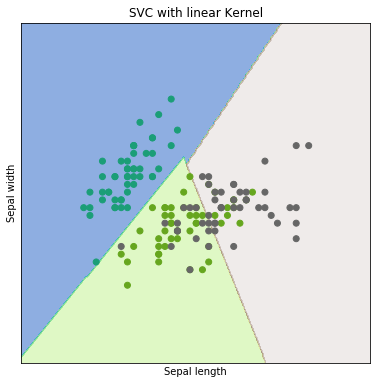

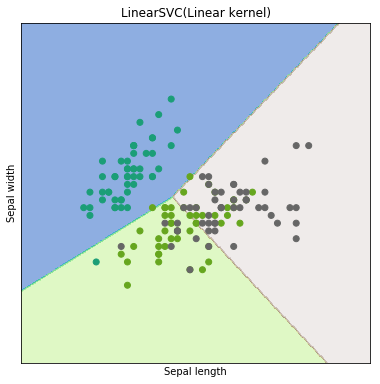

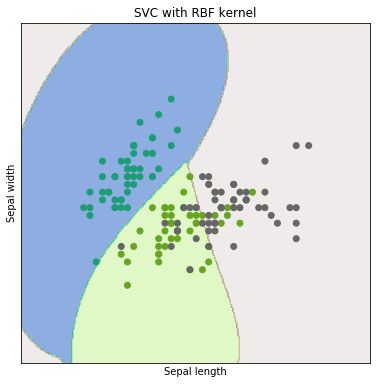

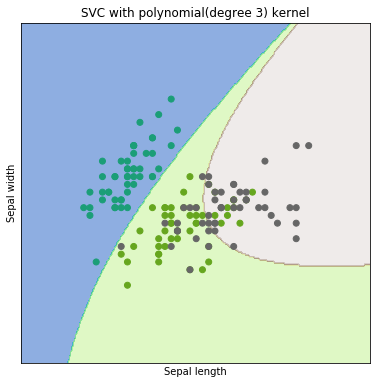

In [10]:
titles =['SVC with linear Kernel',
       'LinearSVC(Linear kernel)',
        'SVC with RBF kernel',
       'SVC with polynomial(degree 3) kernel']

for i, clf in enumerate((linear_svc, lin_svc, rbf_svc, poly_svc)):
    plt.figure(figsize=(15,15))
    plt.subplot(2,2,i+1)
    plt.subplots_adjust(wspace=0.4, hspace=0.4)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z =  Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.terrain, alpha=0.5)
    plt.scatter(X[:,0], X[:,1], c=Y, cmap=plt.cm.Dark2)
    
    plt.xlabel('Sepal length')
    plt.ylabel('Sepal width')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    
    plt.xticks(())
    plt.yticks(())
    plt.title(titles[i])

### 3. 2 Same dataset using Naive Bayes therem with Split

In [11]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# split the data
train_X, test_X, train_Y, test_Y = train_test_split(iris.data, iris.target , test_size =0.3)
print(train_X.shape)
print(test_X.shape)

(105, 4)
(45, 4)


In [12]:
gnb_model = GaussianNB()
gnb_model.fit(train_X, train_Y)

#testing
predicted_op = gnb_model.predict(test_X)
accuracy_score(test_Y, predicted_op)


0.9555555555555556

In [22]:
print(pd.DataFrame(test_Y, predicted_op))

   0
2  2
1  1
0  0
2  2
2  2
2  2
1  2
2  2
2  2
1  2
1  1
0  0
2  2
1  1
2  2
0  0
1  1
1  1
1  1
2  2
0  0
2  2
2  2
1  1
1  1
2  2
2  2
2  2
1  1
1  1
2  2
0  0
1  1
1  1
1  1
0  0
2  2
0  0
1  1
2  2
2  2
1  1
1  1
0  0
1  1


### 3. 2 Same dataset using Naive Bayes therem without Split

In [26]:
#Withot split
gnb_model1 = GaussianNB()
gnb_model1.fit(iris.data, iris.target)

#testing;;;;;;;
predicted_op1 = gnb_model1.predict(iris.data)
accuracy_score(iris.target, predicted_op1)


0.96

## 4 Model Evaluation

### 4.1. Model Evaluation  - Accuracy Score

In [29]:

print("Naive Bayes with split :" ,accuracy_score(test_Y, predicted_op))

print("Naive Bayes without split:" ,accuracy_score(iris.target, predicted_op1))

Naive Bayes with split : 0.9555555555555556
Naive Bayes without split: 0.96


### 4.2. Model Evaluation - confusion_matrix  

In [32]:

print("Naive Bayes with split \n" ,confusion_matrix(test_Y, predicted_op))

#Only 2 places it gave wrong prediction, remaing all cases correct


print("\n Naive Bayes without split \n " ,confusion_matrix(iris.target, predicted_op1))

Naive Bayes with split 
 [[ 8  0  0]
 [ 0 17  0]
 [ 0  2 18]]

 Naive Bayes without split 
  [[50  0  0]
 [ 0 47  3]
 [ 0  3 47]]


Naive Bayes with split 



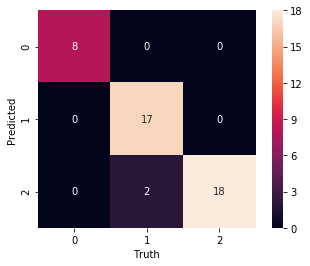


 Naive Bayes without split 
 


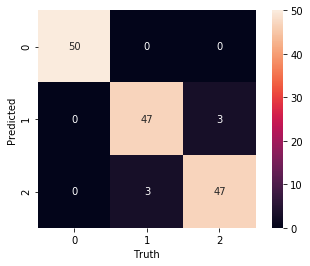

In [34]:
import matplotlib.pyplot as plt


print("Naive Bayes with split \n" )

labels = np.unique(predicted_op)
mat = confusion_matrix(test_Y, predicted_op)
sns.heatmap(mat,
            fmt='d',
            square=True,
            cbar=True,
            annot=True,
            xticklabels=labels,
            yticklabels=labels) # This should be distinct classes

#le.classes_
plt.xlabel('Truth'),
plt.ylabel('Predicted')
plt.show()
print("\n Naive Bayes without split \n ")

mat1 = confusion_matrix(iris.target, predicted_op1)
sns.heatmap(mat1,
            fmt='d',
            square=True,
            cbar=True,
            annot=True,
            xticklabels=labels,
            yticklabels=labels) # This should be distinct classes

#le.classes_
plt.xlabel('Truth'),
plt.ylabel('Predicted')
plt.show()

### 4.3. Model Evaluation - classification_report  

In [35]:
# classification_report

# Here we need to give categorial value instead of label encoded value. It will be easy to interpretate
print("Naive Bayes confusion_matrix \n:" ,classification_report(test_Y, predicted_op))

print("\n Naive Bayes with split \n ",classification_report(iris.target, predicted_op1))


Naive Bayes confusion_matrix 
:               precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.89      1.00      0.94        17
           2       1.00      0.90      0.95        20

   micro avg       0.96      0.96      0.96        45
   macro avg       0.96      0.97      0.96        45
weighted avg       0.96      0.96      0.96        45


 Naive Bayes with split 
                precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.94      0.94      0.94        50
           2       0.94      0.94      0.94        50

   micro avg       0.96      0.96      0.96       150
   macro avg       0.96      0.96      0.96       150
weighted avg       0.96      0.96      0.96       150



## 5. Conclusion

<div class="alert" style="background-color:#906969; color:white; padding:0px 10px; border-radius:5px;">
<h3 style='margin:15px 15px; font-size:25px'> 
By This SVC and Naivy bayes, looks Naivy gives good prediction</h3>
</div>

<div class="alert" style="background-color:#696969; color:white; padding:0px 10px; border-radius:5px;">
<h3 style='margin:15px 15px; font-size:12px'> 
All Rights Reserved. This notebook is proprietary content of Prayog. 
This can be shared solely for educational purposes, with due credits to machinelearningplus.com</h3>
</div>
